In [16]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

In [29]:
#data_path = "/home/korach/mich/${paths.data_dir}/julie-sim.h5"

data_path = "/home/korach/mich/single_linear_10x10.h5"

In [30]:
with h5py.File(data_path, "r") as file:
    bold = np.stack([file[layer]["bold"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    x = np.stack([file[layer]["x"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    s = np.stack([file[layer]["s"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    f = np.stack([file[layer]["f"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    v = np.stack([file[layer]["v"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    q = np.stack([file[layer]["q"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    v_star = np.stack(
        [file[layer]["v_star"][:50] for layer in file.keys() if "layer" in layer], axis=1
    )
    q_star = np.stack(
        [file[layer]["q_star"][:50] for layer in file.keys() if "layer" in layer], axis=1
    )

    source_location = file["meta"]["source_layer"][:50]
    source_pos = file["meta"]["source_position"][:50]

In [32]:
print("Data shapes:")
print("BOLD:", bold.shape)
print("x:", x.shape)
print("s:", s.shape)
print("f:", f.shape)
print("v:", v.shape)
print("q:", q.shape)
print("v*:", v_star.shape)
print("q*:", q_star.shape)
print("Source location:", source_location)
print("Source position:", source_pos)

Data shapes:
BOLD: (50, 1, 100, 10, 10)
x: (50, 1, 100, 10, 10)
s: (50, 1, 100, 10, 10)
f: (50, 1, 100, 10, 10)
v: (50, 1, 100, 10, 10)
q: (50, 1, 100, 10, 10)
v*: (50, 1, 100, 10, 10)
q*: (50, 1, 100, 10, 10)
Source location: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Source position: [[0 6]
 [0 4]
 [5 5]
 [4 9]
 [7 7]
 [1 1]
 [8 6]
 [5 6]
 [4 5]
 [9 4]
 [1 8]
 [3 2]
 [4 2]
 [5 8]
 [0 3]
 [9 3]
 [5 6]
 [1 7]
 [5 2]
 [1 6]
 [2 3]
 [6 3]
 [5 6]
 [5 1]
 [9 6]
 [7 6]
 [7 5]
 [4 7]
 [0 0]
 [5 5]
 [4 4]
 [7 0]
 [5 3]
 [4 4]
 [0 6]
 [8 3]
 [5 1]
 [1 1]
 [4 6]
 [4 6]
 [7 7]
 [7 4]
 [5 1]
 [7 9]
 [7 2]
 [4 0]
 [2 0]
 [6 3]
 [9 9]
 [4 2]]


Source layer: 0, Source position: [4 9]


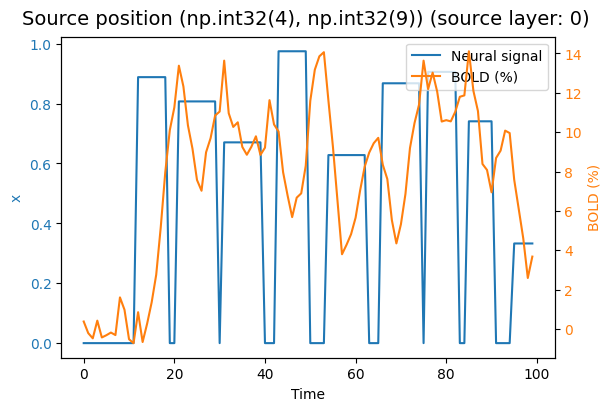

In [37]:
data_idx = np.random.randint(0, bold.shape[0])
slayer = source_location[data_idx]
spos = source_pos[data_idx]
print(f"Source layer: {slayer}, Source position: {spos}")

n_layers = x.shape[1]

fig, ax = plt.subplots(
    nrows=n_layers, ncols=1, figsize=(6, 4), sharex=True, constrained_layout=True
)





x_sig = x[data_idx, 0, :, *spos]
bold_sig = bold[data_idx, 0, :, *spos]

(l1,) = ax.plot(x_sig, color="tab:blue", label="Neural signal")
ax.set_ylabel(f"x", color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax.twinx()
(l2,) = ax2.plot(bold_sig * 100, color="tab:orange", label="BOLD (%)")
ax2.set_ylabel(f"BOLD (%)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax.legend(handles=[l1, l2], loc="upper right")

ax.set_xlabel("Time")
fig.suptitle(f"Source position {tuple(spos)} (source layer: {slayer})", fontsize=14)
plt.show()

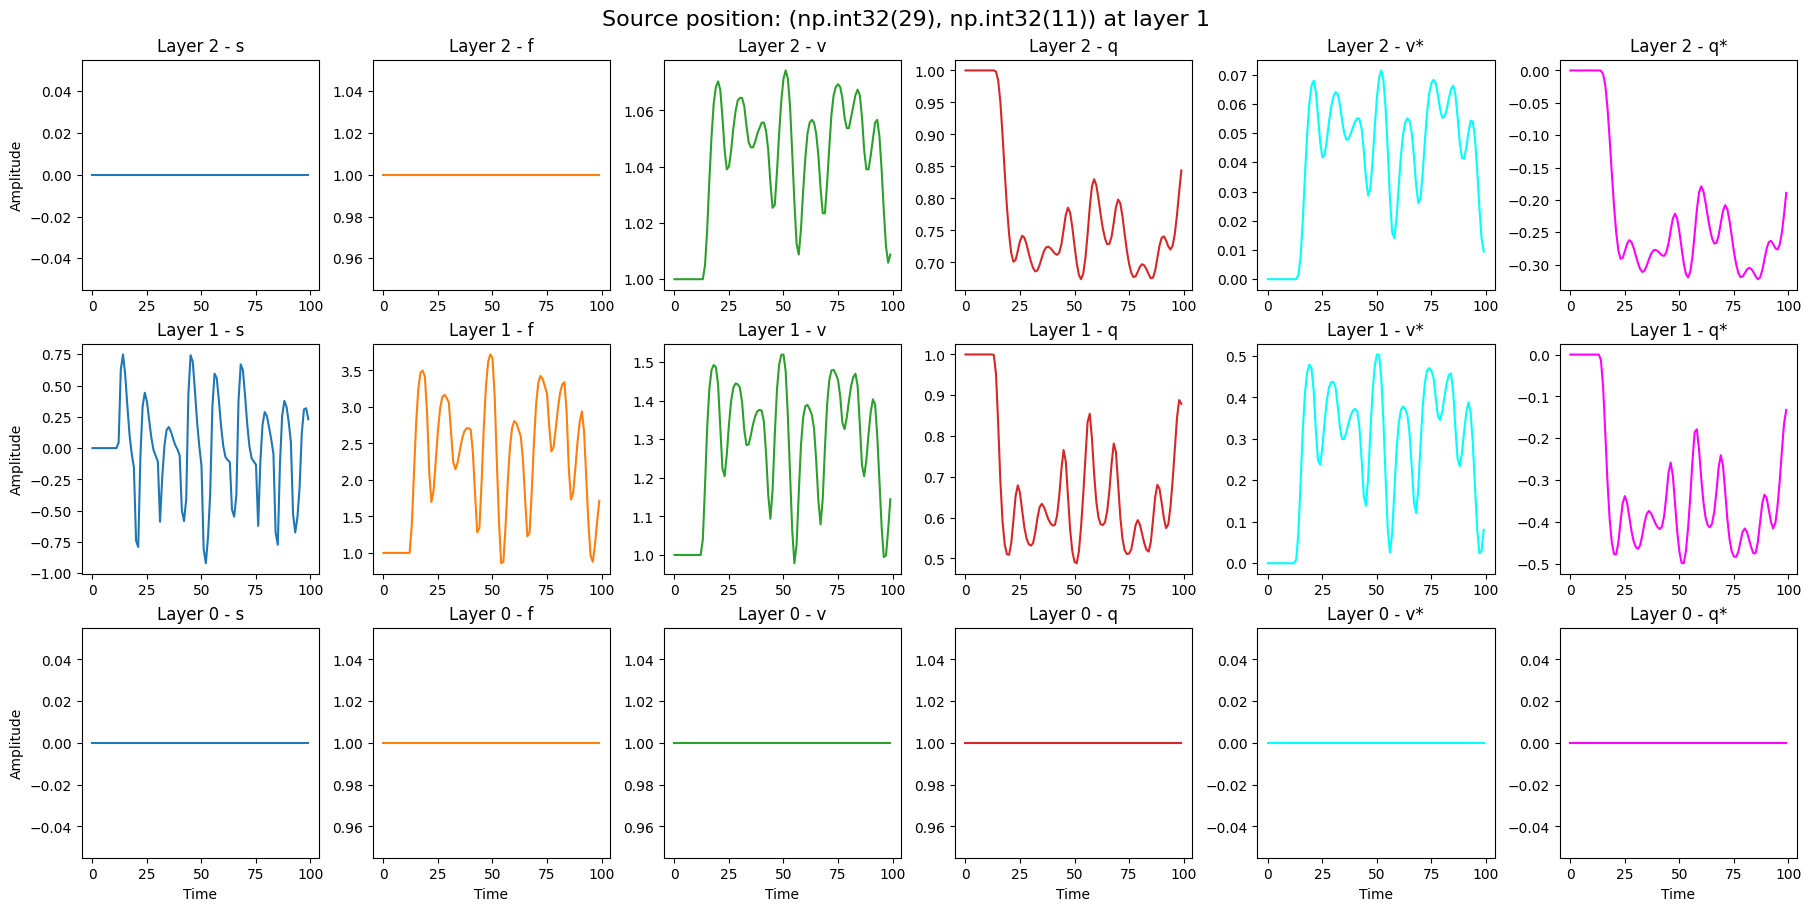

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=6, figsize=(18, 9), constrained_layout=True)

n_layers = s.shape[1]  # expected 3

for i in range(n_layers):
    row = n_layers - 1 - i  # deepest at bottom

    ax[row, 0].plot(s[data_idx, i, :, *spos], color="tab:blue")
    ax[row, 0].set_title(f"Layer {i} - s")

    ax[row, 1].plot(f[data_idx, i, :, *spos], color="tab:orange")
    ax[row, 1].set_title(f"Layer {i} - f")

    ax[row, 2].plot(v[data_idx, i, :, *spos], color="tab:green")
    ax[row, 2].set_title(f"Layer {i} - v")

    ax[row, 3].plot(q[data_idx, i, :, *spos], color="tab:red")
    ax[row, 3].set_title(f"Layer {i} - q")

    ax[row, 4].plot(v_star[data_idx, i, :, *spos], color="cyan")
    ax[row, 4].set_title(f"Layer {i} - v*")

    ax[row, 5].plot(q_star[data_idx, i, :, *spos], color="magenta")
    ax[row, 5].set_title(f"Layer {i} - q*")

for r in range(n_layers):
    ax[r, 0].set_ylabel("Amplitude")
for c in range(6):
    ax[-1, c].set_xlabel("Time")

plt.suptitle(f"Source position: {tuple(spos)} at layer {slayer}", fontsize=16)
plt.show()

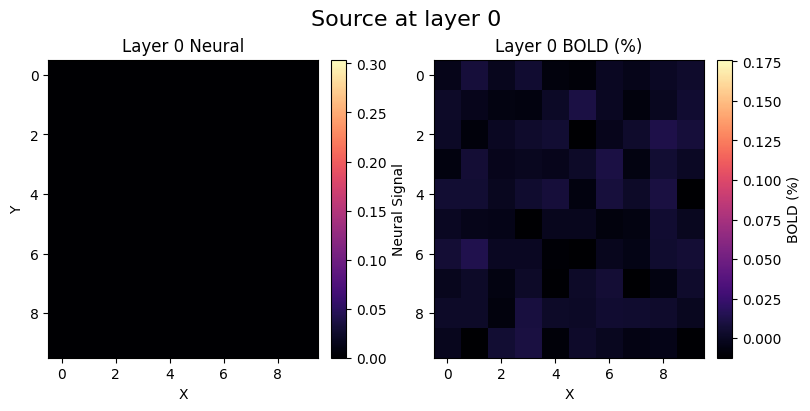

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4), constrained_layout=True)

# Use full time dimension (100), not a single time index
bold_sig = bold[data_idx]  # shape: (layers, time, y, x)
neural_sig = x[data_idx]  # shape: (layers, time, y, x)
nlayers = bold_sig.shape[0]

bold_min, bold_max = np.quantile(bold_sig, 0.01), np.quantile(bold_sig, 0.99)
neural_min, neural_max = np.quantile(neural_sig, 0.01), np.quantile(neural_sig, 0.99)

fig.suptitle(f"Source at layer {slayer}", fontsize=16)

# Keep image handles for animation updates
img_neural = []
img_bold = []



n_im = ax[0].imshow(
    neural_sig[0, 0], aspect="auto", cmap="magma", vmin=neural_min, vmax=neural_max
)
b_im = ax[1].imshow(
    bold_sig[0, 0], aspect="auto", cmap="magma", vmin=bold_min, vmax=bold_max
)

img_neural.append(n_im)
img_bold.append(b_im)

ax[0].set_title(f"Layer {i} Neural")
ax[1].set_title(f"Layer {i} BOLD (%)")
ax[0].set_ylabel("Y")

# Add only one colorbar per column
fig.colorbar(img_neural[0], ax=ax[0], orientation="vertical", label="Neural Signal")
fig.colorbar(img_bold[0], ax=ax[1], orientation="vertical", label="BOLD (%)")

for c in range(2):
    ax[c].set_xlabel("X")


def update_frame(t):
    for layer in range(nlayers):
        img_neural[layer].set_data(neural_sig[layer, t])
        img_bold[layer].set_data(bold_sig[layer, t])
    return img_neural + img_bold


ani = FuncAnimation(fig, update_frame, frames=bold_sig.shape[1], repeat=True)
plt.show()

In [22]:
ani.save("bold_neural_animation.gif", writer="pillow", fps=3)